## Section 29.16: A retrieval-augmented variant -- RWKV's recollection as a search query, not evidence

Section 27 named the gap this fills: *"Where a retrieval-augmented design would plug in (not
implemented)."* Section 29 tested RWKV-7's recurrent state as a memory store by handing its short
`Facts:/Answer:` note to Llama **as evidence** (`rwkvmem`) -- Llama reads the note and answers from
it, never seeing the raw session text. This section asks a different question, inspired by MemoRAG
(Qian et al., WWW 2025): what if that same note is used only to **decide what to retrieve**, and
Llama then answers from the *real* sessions BM25 pulls back, not from the note itself?

**What is borrowed from MemoRAG, and what is not.** MemoRAG's core idea -- a memory model's own
draft answer, generated cheaply from a global view of the corpus, used as a retrieval *clue* rather
than handed to the reader directly -- is the one thing this section adapts. Everything else about
MemoRAG's actual architecture is out of scope and not implemented here: no KV-cache compression, no
memory model trained end-to-end for this task (RWKV-7 G1 is a general-purpose off-the-shelf
checkpoint, exactly as in Section 29), and no evaluation against MemoRAG's own benchmark suite. This
is a small, targeted adaptation of one idea to this notebook's existing 100-question LongMemEval
setup, not a MemoRAG reproduction.

**The mechanism.** For each question, index that question's own ~47 S-arm sessions with BM25
(`rank_bm25`), query the index with RWKV's note text, take the top-k sessions, and render them with
the same `render_history()` the `oracle`/`s` arms already use -- so the reader-facing prompt is
apples-to-apples with those arms in shape, differing only in *which* sessions are included and how
they were chosen. `rwkvmem-retrieval-k{3,6,10}` sweeps k because the right retrieval depth isn't
known in advance: too small and the answer-bearing session may be missed, too large and this
degenerates back toward the `s` arm's information overload.

**The load-bearing control: `qretrieval`.** Identical pipeline, but the query is the raw question
text instead of RWKV's note. This isolates the one variable actually in question -- does RWKV's
recollection add anything as a *query* over plain-question retrieval? **State this plainly before
any results exist: LongMemEval's question types are largely explicit-intent (the question itself
names what it's asking about), so plain-question BM25 over a modest ~47-session haystack may already
capture most of the achievable gain. A null result -- `rwkvmem-retrieval` failing to beat
`qretrieval` at matching k -- is therefore a legitimate, expected-possible outcome of this design,
not evidence of a bug.** If anything separates the two, the most likely place to find it is where
the question's own wording is a weaker retrieval cue than a synthesized recollection: multi-session,
knowledge-update, and preference questions, where an answer depends on synthesizing across sessions
the question text alone may not obviously name. Single-session-user/assistant questions, whose
answer session the question already all but names, are the condition where a null result is most
expected.

**Design choices, and why.**
- **BM25, not RWKV's own recollection, does the ranking.** RWKV's note is only ever a query string
  here -- the reader never sees it, unlike `rwkvmem`. This is what makes this a genuinely different
  design from Section 29's, not a renamed variant of it.
- **Per-question index, not one corpus-wide index.** Each question's haystack is already scoped to
  its own sessions (Section 7's dataset construction), so indexing per-question is both correct
  (there is no cross-question retrieval to do) and cheap (~47 documents, negligible BM25 build time).
- **k in {3, 6, 10}.** The oracle arm's answer-bearing sessions number 2 on average in this subset
  (measured), so k=3 already gives real headroom to include the true evidence purely by BM25 rank;
  k=10 pushes toward the `s` arm's exhaustive-history regime while staying well under Llama's
  context budget (measured: ~32k tokens at k=10, against a ~126.5k-token budget).
- **`render_history()` reused unchanged**, not a bespoke retrieval-prompt format -- the whole point
  is that these arms differ from `oracle`/`s` only in *which* sessions are shown, not in *how*.

**What to actually expect.** Two outcomes are both legitimate results, not failures:
(1) `rwkvmem-retrieval` beats `qretrieval` -- RWKV's synthesized recollection is a better search
query than the bare question, likely concentrated in the multi-session/knowledge-update/preference
types named above; or (2) it does not -- plain-question BM25 was already close to whatever a
~47-session haystack allows, and the gap this section closes (if any) is retrieval itself, not
RWKV's contribution to it. Either way, comparing both against `s`, `oracle`, and `closedbook`
(Sections 29.23-29.24) is what makes the result interpretable rather than a single unexplained
number.

### 29.17 Installing the retrieval dependency

`rank_bm25` is the only new dependency this section needs -- same skip-if-present /
`pip install -q` pattern as Section 2.

In [5]:
import importlib.util
import subprocess
import sys

_REQUIRED_2917 = {"rank_bm25": "rank_bm25>=0.2.2"}
_missing_2917 = [pip_name for mod_name, pip_name in _REQUIRED_2917.items()
                 if importlib.util.find_spec(mod_name) is None]
if _missing_2917:
    print(f"Installing {len(_missing_2917)} missing package(s): {_missing_2917}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing_2917], check=True)
else:
    print("All required packages already present.")

from rank_bm25 import BM25Okapi
print("rank_bm25 ready.")

All required packages already present.
rank_bm25 ready.


### 29.18 Bootstrap -- rebuilding everything this section needs, without re-running Sections 1-28 or 29.1-29.15

Same `_reuse_or_build` pattern as 29.2: reuses this kernel's globals() where already present
(e.g. if this notebook happens to be run in a kernel that already has `long_mem_eval_v1.ipynb`'s
state loaded), otherwise rebuilds from disk / the live OpenRouter API. Nothing here writes to
anything Sections 1-28 or 29.1-29.15 already produced -- only reads. `render_session()`,
`render_history()`, `PROMPT_TEMPLATE_DIRECT`, `compute_metrics()`, `wilson_ci()`, and
`mcnemar_exact_p()` are transcribed here rather than imported (a notebook cannot import from
another notebook); **Gate F**, at the end of this cell, checks that transcription against
`long_mem_eval_v1.ipynb`'s live source instead of merely asserting it still matches.

This cell also checks whether RWKV's memory notes (`_notes_by_id`, built by that notebook's
Sections 29.1-29.9) are present on disk. If they are not -- the case on this machine, where those
sections were never run to completion -- `CAN_RUN_RWKVMEM_RETRIEVAL` is set `False` and the three
`rwkvmem-retrieval-k{3,6,10}` arms are skipped everywhere below with a printed reason; the three
`qretrieval-k{3,6,10}` arms need no notes and always run.

In [6]:
"""29.18 bootstrap. Reuses this kernel's globals() where present; rebuilds from disk / the
live OpenRouter API otherwise -- same pattern as long_mem_eval_v1.ipynb's own 29.2, since this
notebook is a standalone continuation of that one (Sections 1-28 and 29.1-29.15 are not modified,
only read from disk)."""
import getpass
import json as _json
import math
import os
import random
import re
import sys
import time
import urllib.request
from pathlib import Path

_BOOTSTRAP_LOG = []


def _reuse_or_build(name, builder):
    if name in globals() and globals()[name] is not None:
        _BOOTSTRAP_LOG.append((name, "reused (already in this kernel)"))
        return globals()[name]
    value = builder()
    globals()[name] = value
    _BOOTSTRAP_LOG.append((name, "rebuilt from disk / API"))
    return value


# --- environment + paths (Sections 1 and 4) ---
IN_COLAB = _reuse_or_build("IN_COLAB", lambda: "google.colab" in sys.modules)


def _build_root():
    root_name = "lme_openrouter"
    if IN_COLAB:
        from google.colab import drive
        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive/Algoverse") / root_name
    root = Path.cwd() / root_name
    if not root.exists():
        # Guard against this notebook being launched from the repo root instead of
        # paper_recreation/ -- matches long_mem_eval_v1.ipynb's own 29.2 guard.
        alt = Path.cwd() / "paper_recreation" / root_name
        if alt.parent.exists():
            return alt
    return root


ROOT = _reuse_or_build("ROOT", _build_root)
RUN_SCALE = _reuse_or_build("RUN_SCALE", lambda: "subset100")
if RUN_SCALE != "subset100":
    raise RuntimeError(
        f"This notebook compares against the 100-question baseline numbers already measured for "
        f"'subset100'; found RUN_SCALE={RUN_SCALE!r} in this kernel. Restart the kernel before "
        f"running this notebook standalone."
    )
DATA_ROOT = _reuse_or_build("DATA_ROOT", lambda: ROOT / "data")
RUN_ROOT = _reuse_or_build("RUN_ROOT", lambda: ROOT / "runs" / RUN_SCALE)
RESULTS_ROOT = _reuse_or_build("RESULTS_ROOT", lambda: ROOT / "results" / RUN_SCALE)
FIGURES_ROOT = _reuse_or_build("FIGURES_ROOT", lambda: RESULTS_ROOT / "figures")
GENERATIONS_ROOT = _reuse_or_build("GENERATIONS_ROOT", lambda: RUN_ROOT / "generations")
JUDGED_ROOT = _reuse_or_build("JUDGED_ROOT", lambda: RUN_ROOT / "judged")
for _dir in (DATA_ROOT, RUN_ROOT, RESULTS_ROOT, FIGURES_ROOT, GENERATIONS_ROOT, JUDGED_ROOT):
    _dir.mkdir(parents=True, exist_ok=True)


# --- API keys (Section 5) ---
def get_secret(env_name: str) -> str:
    if os.environ.get(env_name):
        return os.environ[env_name]
    if IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(env_name)
            if val:
                os.environ[env_name] = val
                return val
        except Exception:
            pass
    if not sys.stdin.isatty():
        raise RuntimeError(
            f"{env_name} was not found in the environment, .env, or Colab secrets, and this "
            f"process has no interactive terminal to prompt for it."
        )
    val = getpass.getpass(f"Enter {env_name} (input hidden): ")
    os.environ[env_name] = val
    return val


if "OPENROUTER_API_KEY" not in os.environ or "OPENAI_API_KEY" not in os.environ:
    from dotenv import find_dotenv, load_dotenv
    _dotenv_path = find_dotenv(usecwd=True)
    if _dotenv_path:
        load_dotenv(_dotenv_path)

OPENAI_API_KEY="INSERT KEY"
OPENROUTER_API_KEY="INSERT KEY"

# --- dataset (Sections 7-8) -- this notebook reuses the already-downloaded files ---
DATASET_PATHS = _reuse_or_build("DATASET_PATHS", lambda: {
    "oracle": DATA_ROOT / "longmemeval_oracle.json",
    "s": DATA_ROOT / "longmemeval_s_cleaned.json",
})
for _key, _path in DATASET_PATHS.items():
    if not _path.exists():
        raise FileNotFoundError(
            f"{_path} not found. This notebook reuses the dataset long_mem_eval_v1.ipynb's "
            f"Section 7 already downloaded -- run that notebook's Sections 1-8 at least once first."
        )


def _load_json(path):
    with open(path, encoding="utf-8") as f:
        return _json.load(f)


oracle_data = _reuse_or_build("oracle_data", lambda: _load_json(DATASET_PATHS["oracle"]))
s_data = _reuse_or_build("s_data", lambda: _load_json(DATASET_PATHS["s"]))
oracle_by_id = _reuse_or_build("oracle_by_id", lambda: {q["question_id"]: q for q in oracle_data})
s_by_id = _reuse_or_build("s_by_id", lambda: {q["question_id"]: q for q in s_data})


# --- the fixed 100-question subset (Section 9) -- read from disk, never re-drawn ---
_subset_path = RESULTS_ROOT / "question_subset_ids.json"
if not _subset_path.exists():
    raise FileNotFoundError(
        f"{_subset_path} not found. This notebook reuses the exact 100-question draw "
        f"long_mem_eval_v1.ipynb's Section 9 already made and saved, so this comparison lands on "
        f"the identical questions as the oracle/s/rwkvmem baselines -- run that notebook's "
        f"Section 9 at least once first."
    )
with open(_subset_path, encoding="utf-8") as f:
    _subset_manifest = _json.load(f)
assert _subset_manifest["n"] == 100, (
    f"{_subset_path} was written for n={_subset_manifest['n']}, expected 100."
)
QUESTION_SUBSET_IDS = _reuse_or_build("QUESTION_SUBSET_IDS", lambda: _subset_manifest["question_ids"])
assert len(QUESTION_SUBSET_IDS) == 100
_missing_o = [qid for qid in QUESTION_SUBSET_IDS if qid not in oracle_by_id]
_missing_s = [qid for qid in QUESTION_SUBSET_IDS if qid not in s_by_id]
assert not _missing_o and not _missing_s, (
    f"question_subset_ids.json references ids missing from the downloaded dataset -- oracle "
    f"missing {_missing_o[:3]}, s missing {_missing_s[:3]}."
)
QUESTION_SUBSET = _reuse_or_build("QUESTION_SUBSET", lambda: [oracle_by_id[qid] for qid in QUESTION_SUBSET_IDS])


# --- prompt/history helpers (Section 10) -- transcribed verbatim; Gate F below checks this ---
def render_session(session_turns: list) -> str:
    cleaned_turns = [
        {k: v for k, v in turn.items() if k != "has_answer"} if isinstance(turn, dict) else turn
        for turn in session_turns
    ]
    return _json.dumps(cleaned_turns)


def render_history(haystack_sessions: list, haystack_dates: list) -> str:
    items = sorted(zip(haystack_dates, haystack_sessions), key=lambda x: x[0])
    parts = []
    for i, (date, session_turns) in enumerate(items):
        sess_string = "\n" + render_session(session_turns)
        parts.append(f"\n### Session {i+1}:\nSession Date: {date}\nSession Content:\n{sess_string}\n")
    return "".join(parts)


PROMPT_TEMPLATE_DIRECT = (
    "I will give you several history chats between you and a user. Please answer the question "
    "based on the relevant chat history.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: "
    "{}\nAnswer:"
)
GEN_LENGTH_BY_READING = {"direct": 500, "con": 800}
TEMPERATURE = 0.0


# --- judge prompts and metrics (Section 10) -- transcribed verbatim; Gate F below checks this ---
_JUDGE_TEMPLATE_STANDARD = (
    "I will give you a question, a correct answer, and a response from a model. Please answer yes "
    "if the response contains the correct answer. Otherwise, answer no. If the response is "
    "equivalent to the correct answer or contains all the intermediate steps to get the correct "
    "answer, you should also answer yes. If the response only contains a subset of the information "
    "required by the answer, answer no. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: "
    "{}\n\nIs the model response correct? Answer yes or no only."
)
_JUDGE_TEMPLATE_TEMPORAL = (
    "I will give you a question, a correct answer, and a response from a model. Please answer yes "
    "if the response contains the correct answer. Otherwise, answer no. If the response is "
    "equivalent to the correct answer or contains all the intermediate steps to get the correct "
    "answer, you should also answer yes. If the response only contains a subset of the information "
    "required by the answer, answer no. In addition, do not penalize off-by-one errors for the "
    "number of days. If the question asks for the number of days/weeks/months, etc., and the model "
    "makes off-by-one errors (e.g., predicting 19 days when the answer is 18), the model's response "
    "is still correct. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the "
    "model response correct? Answer yes or no only."
)
_JUDGE_TEMPLATE_KNOWLEDGE_UPDATE = (
    "I will give you a question, a correct answer, and a response from a model. Please answer yes "
    "if the response contains the correct answer. Otherwise, answer no. If the response contains "
    "some previous information along with an updated answer, the response should be considered as "
    "correct as long as the updated answer is the required answer.\n\nQuestion: {}\n\nCorrect "
    "Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
)
_JUDGE_TEMPLATE_PREFERENCE = (
    "I will give you a question, a rubric for desired personalized response, and a response from a "
    "model. Please answer yes if the response satisfies the desired response. Otherwise, answer no. "
    "The model does not need to reflect all the points in the rubric. The response is correct as "
    "long as it recalls and utilizes the user's personal information correctly.\n\nQuestion: "
    "{}\n\nRubric: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
)
_JUDGE_TEMPLATE_ABSTENTION = (
    "I will give you an unanswerable question, an explanation, and a response from a model. Please "
    "answer yes if the model correctly identifies the question as unanswerable. The model could say "
    "that the information is incomplete, or some other information is given but the asked "
    "information is not.\n\nQuestion: {}\n\nExplanation: {}\n\nResponse: {}\n\nDoes the model "
    "correctly identify the question as unanswerable? Answer yes or no only."
)


def get_judge_prompt(question_type: str, question: str, answer: str, response: str, abstention: bool = False) -> str:
    if abstention:
        return _JUDGE_TEMPLATE_ABSTENTION.format(question, answer, response)
    if question_type in ("single-session-user", "single-session-assistant", "multi-session"):
        return _JUDGE_TEMPLATE_STANDARD.format(question, answer, response)
    if question_type == "temporal-reasoning":
        return _JUDGE_TEMPLATE_TEMPORAL.format(question, answer, response)
    if question_type == "knowledge-update":
        return _JUDGE_TEMPLATE_KNOWLEDGE_UPDATE.format(question, answer, response)
    if question_type == "single-session-preference":
        return _JUDGE_TEMPLATE_PREFERENCE.format(question, answer, response)
    raise NotImplementedError(f"Unknown question_type: {question_type!r}")


EXPECTED_TYPE_COUNTS = {
    "temporal-reasoning": 133, "multi-session": 133, "knowledge-update": 78,
    "single-session-user": 70, "single-session-assistant": 56, "single-session-preference": 30,
}
QUESTION_TYPES = list(EXPECTED_TYPE_COUNTS.keys())


def compute_metrics(records: list) -> dict:
    by_type = {t: [] for t in QUESTION_TYPES}
    abstention_labels = []
    for r in records:
        by_type[r["question_type"]].append(1 if r["label"] else 0)
        if "_abs" in r["question_id"]:
            abstention_labels.append(1 if r["label"] else 0)
    type_acc = {t: (sum(v) / len(v) if v else None) for t, v in by_type.items()}
    present = [v for v in type_acc.values() if v is not None]
    task_averaged = sum(present) / len(present) if present else None
    all_labels = [1 if r["label"] else 0 for r in records]
    overall = sum(all_labels) / len(all_labels) if all_labels else None
    abstention_acc = sum(abstention_labels) / len(abstention_labels) if abstention_labels else None
    return {
        "by_type": type_acc, "task_averaged": task_averaged, "overall": overall,
        "abstention": abstention_acc, "n_by_type": {t: len(v) for t, v in by_type.items()},
        "n_abstention": len(abstention_labels),
    }


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple:
    if n == 0:
        return (None, None)
    phat = k / n
    denom = 1 + z * z / n
    center = phat + z * z / (2 * n)
    margin = z * math.sqrt(phat * (1 - phat) / n + z * z / (4 * n * n))
    return (max(0.0, (center - margin) / denom), min(1.0, (center + margin) / denom))


def mcnemar_exact_p(b: int, c: int) -> float:
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) * (0.5 ** n)
    return min(1.0, 2 * p)


# --- reader routing (Section 6) -- llama-3.1-8b-instruct only; this section doesn't need the
# other three readers ---
READER_SPECS = _reuse_or_build("READER_SPECS", lambda: {
    "llama-3.1-8b-instruct": {
        "openrouter_slug": "meta-llama/llama-3.1-8b-instruct",
        "native_context": 128000,
        "paper_source": "Figure 3b",
        "pinned_provider": "Groq",
        "documented_fallback": "DeepInfra",
        "tokenizer_repo": "unsloth/Llama-3.1-8B-Instruct",
    },
})


def fetch_openrouter_endpoints(slug: str) -> list:
    url = f"https://openrouter.ai/api/v1/models/{slug}/endpoints"
    req = urllib.request.Request(url, headers={"Authorization": f"Bearer {OPENROUTER_API_KEY}"})
    with urllib.request.urlopen(req, timeout=45) as resp:
        return _json.load(resp)["data"]["endpoints"]


def pick_and_verify_provider(reader_name: str, spec: dict) -> dict:
    required_ctx = spec["native_context"]
    endpoints = fetch_openrouter_endpoints(spec["openrouter_slug"])
    by_provider = {e["provider_name"]: e for e in endpoints}
    for candidate, _note in [(spec["pinned_provider"], "pinned"), (spec["documented_fallback"], "fallback")]:
        if candidate is None:
            continue
        ep = by_provider.get(candidate)
        if ep is None or ep["context_length"] < required_ctx:
            continue
        return {
            "provider": candidate, "quantization": ep.get("quantization", "unknown"),
            "context_length": ep["context_length"],
            "price_in": float(ep["pricing"].get("prompt", 0) or 0),
            "price_out": float(ep["pricing"].get("completion", 0) or 0),
        }
    raise RuntimeError(
        f"No usable provider for {reader_name} with >= {required_ctx:,} tokens of context. "
        f"Available: {[(n, e['context_length']) for n, e in by_provider.items()]}"
    )


READER_ROUTING = _reuse_or_build("READER_ROUTING", lambda: {
    "llama-3.1-8b-instruct": pick_and_verify_provider("llama-3.1-8b-instruct", READER_SPECS["llama-3.1-8b-instruct"]),
})


def model2maxlength(reader_name: str) -> int:
    return READER_SPECS[reader_name]["native_context"]


def max_retrieval_length(reader_name: str, reading: str) -> int:
    return model2maxlength(reader_name) - GEN_LENGTH_BY_READING[reading] - 1000


# --- tokenizer (Section 12) -- reuse the already-cached tokenizer file, llama-3.1-8b-instruct only ---
from tokenizers import Tokenizer

_TOKENIZER_CACHE: dict = {}
_TOKENIZER_DIR = DATA_ROOT / "tokenizers"
_TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)


def get_tokenizer(reader_name: str) -> Tokenizer:
    if reader_name not in _TOKENIZER_CACHE:
        repo = READER_SPECS[reader_name]["tokenizer_repo"]
        local_path = _TOKENIZER_DIR / f"{reader_name}.json"
        if not local_path.exists():
            url = f"https://huggingface.co/{repo}/resolve/main/tokenizer.json"
            print(f"  Fetching tokenizer for {reader_name} from {repo} ...")
            urllib.request.urlretrieve(url, local_path)
        _TOKENIZER_CACHE[reader_name] = Tokenizer.from_file(str(local_path))
    return _TOKENIZER_CACHE[reader_name]


# --- generation + judge clients (Sections 15, 20) ---
from openai import OpenAI, APIConnectionError, APIStatusError, RateLimitError

_OR_CLIENT = _reuse_or_build(
    "_OR_CLIENT", lambda: OpenAI(api_key=OPENROUTER_API_KEY, base_url="https://openrouter.ai/api/v1", timeout=240.0)
)
MAX_TRANSIENT_RETRY_ATTEMPTS = 9
TRANSIENT_RETRY_BASE_SECONDS = 5.0
TRANSIENT_RETRY_MAX_SECONDS = 90.0


class GenerationRunFailed(RuntimeError):
    pass


def generate_one(reader_name: str, prompt_rec: dict) -> dict:
    routing = READER_ROUTING[reader_name]
    spec = READER_SPECS[reader_name]
    kwargs = {
        "model": spec["openrouter_slug"],
        "messages": [{"role": "user", "content": prompt_rec["prompt"]}],
        "n": 1, "temperature": TEMPERATURE, "max_tokens": prompt_rec["gen_length"],
    }
    extra_body = {"provider": {"order": [routing["provider"]], "allow_fallbacks": False}}

    def _wait_and_retry(attempts, retry_after, reason):
        wait_s = retry_after if retry_after is not None else min(
            TRANSIENT_RETRY_MAX_SECONDS, TRANSIENT_RETRY_BASE_SECONDS * (2 ** (attempts - 1))
        )
        wait_s += random.uniform(0, wait_s * 0.25)
        print(f"  [retry {attempts}/{MAX_TRANSIENT_RETRY_ATTEMPTS}] {reader_name}/"
              f"{prompt_rec['question_id']}: {reason}. Waiting {wait_s:.1f}s.")
        time.sleep(wait_s)

    attempts = 0
    while True:
        try:
            t0 = time.time()
            completion = _OR_CLIENT.chat.completions.create(**kwargs, extra_body=extra_body)
            latency_s = time.time() - t0
            if completion.choices:
                break
            attempts += 1
            if attempts >= MAX_TRANSIENT_RETRY_ATTEMPTS:
                raise GenerationRunFailed(
                    f"{reader_name}/{prompt_rec['question_id']}: giving up after {attempts} "
                    f"attempt(s): empty choices, error={getattr(completion, 'error', None)!r}"
                )
            _wait_and_retry(attempts, None, f"empty response (error={getattr(completion, 'error', None)!r})")
        except (RateLimitError, APIStatusError, APIConnectionError, _json.JSONDecodeError) as e:
            status = getattr(e, "status_code", None)
            no_endpoints = status == 404 and "no endpoints found" in str(e).lower()
            retryable = (
                isinstance(e, (RateLimitError, APIConnectionError, _json.JSONDecodeError))
                or (status is not None and 500 <= status < 600)
                or no_endpoints
            )
            attempts += 1
            if not retryable or attempts >= MAX_TRANSIENT_RETRY_ATTEMPTS:
                raise GenerationRunFailed(
                    f"{reader_name}/{prompt_rec['question_id']}: giving up after {attempts} "
                    f"attempt(s): {e!r}"
                ) from e
            response_obj = getattr(e, "response", None) if not isinstance(e, _json.JSONDecodeError) else None
            header_val = response_obj.headers.get("retry-after") if response_obj is not None else None
            try:
                retry_after = float(header_val) if header_val is not None else None
            except ValueError:
                retry_after = None
            _wait_and_retry(attempts, retry_after, f"{e.__class__.__name__} (status {status})")

    choice = completion.choices[0]
    usage = completion.usage
    served_provider = getattr(completion, "provider", None)
    return {
        "question_id": prompt_rec["question_id"], "reader": reader_name, "reading": prompt_rec["reading"],
        "hypothesis": (choice.message.content or "").strip(), "finish_reason": choice.finish_reason,
        "provider": served_provider,
        "prompt_tokens": usage.prompt_tokens if usage else None,
        "completion_tokens": usage.completion_tokens if usage else None,
        "cost_usd": getattr(usage, "cost", None) if usage else None, "latency_s": latency_s,
    }


_JUDGE_CLIENT = _reuse_or_build("_JUDGE_CLIENT", lambda: OpenAI(api_key=OPENAI_API_KEY, timeout=120.0))
JUDGE_MODEL = "gpt-4o-2024-08-06"
JUDGE_MAX_RETRY_ATTEMPTS = 6
JUDGE_RETRY_BASE_SECONDS = 5.0
JUDGE_RETRY_MAX_SECONDS = 60.0


def judge_one(gen_record: dict) -> dict:
    q = oracle_by_id[gen_record["question_id"]]   # question/answer text is identical in oracle_data and s_data
    prompt = get_judge_prompt(
        q["question_type"], q["question"], q["answer"], gen_record["hypothesis"],
        abstention="_abs" in q["question_id"],
    )
    attempts = 0
    while True:
        try:
            completion = _JUDGE_CLIENT.chat.completions.create(
                model=JUDGE_MODEL, messages=[{"role": "user", "content": prompt}],
                n=1, temperature=0, max_tokens=10,
            )
            break
        except (RateLimitError, APIStatusError, APIConnectionError) as e:
            status = getattr(e, "status_code", None)
            retryable = isinstance(e, (RateLimitError, APIConnectionError)) or (status is not None and 500 <= status < 600)
            attempts += 1
            if not retryable or attempts >= JUDGE_MAX_RETRY_ATTEMPTS:
                raise GenerationRunFailed(f"judge/{gen_record['question_id']}: giving up: {e!r}") from e
            wait_s = min(JUDGE_RETRY_MAX_SECONDS, JUDGE_RETRY_BASE_SECONDS * (2 ** (attempts - 1)))
            wait_s += random.uniform(0, wait_s * 0.25)
            print(f"  [judge retry {attempts}/{JUDGE_MAX_RETRY_ATTEMPTS}] {gen_record['question_id']}: "
                  f"{e.__class__.__name__}. Waiting {wait_s:.1f}s.")
            time.sleep(wait_s)

    reply = (completion.choices[0].message.content or "").strip()
    return {
        "question_id": gen_record["question_id"], "reader": gen_record["reader"],
        "reading": gen_record["reading"], "question_type": q["question_type"],
        "label": "yes" in reply.lower(), "judge_raw": reply,
    }


def generation_path(reader_name, arm, reading):
    return GENERATIONS_ROOT / reader_name / f"{arm}_{reading}.jsonl"


def judged_path(reader_name, arm, reading):
    return JUDGED_ROOT / reader_name / f"{arm}_{reading}.jsonl"


def run_judge_arm(reader_name, arm, reading):
    import concurrent.futures as cf
    from tqdm.auto import tqdm

    gen_path = generation_path(reader_name, arm, reading)
    with open(gen_path, encoding="utf-8") as f:
        gen_records = [_json.loads(line) for line in f]

    out_path = judged_path(reader_name, arm, reading)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    done_ids = set()
    if out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            for line in f:
                done_ids.add(_json.loads(line)["question_id"])

    todo = [r for r in gen_records if r["question_id"] not in done_ids]
    if not todo:
        print(f"  {reader_name}/{arm}/{reading}: all {len(gen_records)} already judged, skipping.")
        return
    print(f"  {reader_name}/{arm}/{reading}: judging {len(todo)} of {len(gen_records)} "
          f"(already have {len(done_ids)}) ...")
    with open(out_path, "a", encoding="utf-8") as out_f:
        with cf.ThreadPoolExecutor(max_workers=4) as ex:
            futures = {ex.submit(judge_one, r): r for r in todo}
            for fut in tqdm(cf.as_completed(futures), total=len(futures), desc=f"judge {reader_name}/{arm}/{reading}"):
                result = fut.result()
                out_f.write(_json.dumps(result) + "\n")
                out_f.flush()


# --- run_synthetic_arm / build_synthetic_prompt_rec (29.10's pattern) ---
import concurrent.futures as cf
from tqdm.auto import tqdm


def build_synthetic_prompt_rec(question_id: str, prompt_text: str, gen_length: int = 500) -> dict:
    """generate_one() only reads question_id/reading/prompt/gen_length off its prompt_rec argument
    -- this builds the minimal record needed to reuse it for prompts built directly here rather
    than through Section 13's tokenizer-based cache, same as 29.10's version."""
    return {"question_id": question_id, "reading": "direct", "prompt": prompt_text, "gen_length": gen_length}


RETRIEVAL_CONCURRENCY = 2   # deliberately NOT 29.3's RWKVMEM_CONCURRENCY=4: that value was
# justified by ~300-token rwkvmem/closedbook prompts. Retrieval prompts here are 9k-32k tokens (k
# full sessions), and long_mem_eval_v1.ipynb's own cell 6 already recorded Groq 429-storming this
# same reader under sustained concurrent load.


def run_synthetic_arm(reader_name: str, arm: str, questions: list, prompt_fn):
    """Same resumable, skip-what's-cached, hard-stop-on-failure shape as long_mem_eval_v1.ipynb's
    run_arm()/29.10's run_synthetic_arm() -- reimplemented here (a notebook cannot import from
    another notebook) rather than a new design."""
    gen_path = generation_path(reader_name, arm, "direct")
    gen_path.parent.mkdir(parents=True, exist_ok=True)
    done_ids = set()
    if gen_path.exists():
        with open(gen_path, encoding="utf-8") as f:
            for line in f:
                done_ids.add(_json.loads(line)["question_id"])

    expected_ids = {q["question_id"] for q in questions}
    todo = [q for q in questions if q["question_id"] not in done_ids]
    if not todo:
        print(f"  {reader_name}/{arm}/direct: all {len(questions)} already generated, skipping.")
        return

    print(f"  {reader_name}/{arm}/direct: generating {len(todo)} of {len(questions)} "
          f"(already have {len(done_ids)}) ...")
    with open(gen_path, "a", encoding="utf-8") as out_f:
        with cf.ThreadPoolExecutor(max_workers=RETRIEVAL_CONCURRENCY) as ex:
            futures = {
                ex.submit(generate_one, reader_name, build_synthetic_prompt_rec(q["question_id"], prompt_fn(q))): q
                for q in todo
            }
            try:
                for fut in tqdm(cf.as_completed(futures), total=len(futures), desc=f"{reader_name}/{arm}"):
                    result = fut.result()
                    out_f.write(_json.dumps(result) + "\n")
                    out_f.flush()
            except GenerationRunFailed:
                for f2 in futures:
                    f2.cancel()
                raise

    final_ids = set()
    with open(gen_path, encoding="utf-8") as f:
        for line in f:
            final_ids.add(_json.loads(line)["question_id"])
    assert final_ids == expected_ids, (
        f"{reader_name}/{arm}: expected {len(expected_ids)} generations, have {len(final_ids)}. "
        f"Missing: {list(expected_ids - final_ids)[:5]}"
    )


# --- RWKV notes (built by long_mem_eval_v1.ipynb's Section 29.9) -- needed only for the
# rwkvmem-retrieval arms; qretrieval needs none of this ---
RWKV_ARM_NAME = "rwkv7-g1-2.9b"
_notes_path = RUN_ROOT / "rwkv_notes" / RWKV_ARM_NAME / "s_dialogue.jsonl"
CAN_RUN_RWKVMEM_RETRIEVAL = _notes_path.exists() and _notes_path.stat().st_size > 0
_notes_by_id = {}
if CAN_RUN_RWKVMEM_RETRIEVAL:
    with open(_notes_path, encoding="utf-8") as f:
        for line in f:
            rec = _json.loads(line)
            _notes_by_id[rec["question_id"]] = rec
    _missing_notes = [qid for qid in QUESTION_SUBSET_IDS if qid not in _notes_by_id]
    if _missing_notes:
        CAN_RUN_RWKVMEM_RETRIEVAL = False
        print(f"  WARNING: {_notes_path} exists but is missing {len(_missing_notes)} of 100 notes "
              f"-- treating rwkvmem-retrieval as unavailable.")
else:
    print(f"NOTE: {_notes_path} is missing or empty. long_mem_eval_v1.ipynb's Sections 29.1-29.9 "
          f"(RWKV note-building) were not completed against this ROOT -- the three "
          "rwkvmem-retrieval-k{3,6,10} arms cannot run here. The three qretrieval-k{3,6,10} "
          "arms need no notes and will still run below. Build the notes by running that "
          "notebook's Sections 29.1-29.9 (they write to exactly this path) and re-run this "
          "notebook to add the rwkvmem-retrieval arms.")

print(f"CAN_RUN_RWKVMEM_RETRIEVAL = {CAN_RUN_RWKVMEM_RETRIEVAL}  ({len(_notes_by_id)} notes found "
      f"at {_notes_path})")


# --- Gate F: fidelity check -- render_session()/render_history()/PROMPT_TEMPLATE_DIRECT above are
# transcribed from long_mem_eval_v1.ipynb's Section 10, not imported (a notebook cannot import
# from another notebook). This proves the transcription still matches instead of merely asserting
# it -- the same idea as that notebook's own Gate 2 (Section 11), turned inward on a sibling
# notebook instead of the paper's upstream repo. ---
def _gate_f_fidelity_check():
    import ast
    import inspect

    sibling_path = Path.cwd() / "long_mem_eval_v1.ipynb"
    if not sibling_path.exists():
        sibling_path = Path.cwd() / "paper_recreation" / "long_mem_eval_v1.ipynb"
    if not sibling_path.exists():
        print(f"  WARNING: could not find long_mem_eval_v1.ipynb near {Path.cwd()} -- skipping "
              f"Gate F (warn, not fail).")
        return
    with open(sibling_path, encoding="utf-8") as f:
        sibling_nb = _json.load(f)
    sibling_code_cells = ["".join(cell["source"]) for cell in sibling_nb["cells"] if cell["cell_type"] == "code"]

    n_checked, n_passed = 0, 0

    # PROMPT_TEMPLATE_DIRECT is a plain string constant -- Gate 2's own technique (string-literal
    # membership via ast) applies directly.
    n_checked += 1
    all_literals = set()
    for src in sibling_code_cells:
        try:
            all_literals |= {n.value for n in ast.walk(ast.parse(src))
                              if isinstance(n, ast.Constant) and isinstance(n.value, str)}
        except SyntaxError:
            continue
    ok = PROMPT_TEMPLATE_DIRECT in all_literals
    n_passed += ok
    print(f"  [{'OK' if ok else 'MISMATCH'}] PROMPT_TEMPLATE_DIRECT is {'an exact' if ok else 'NOT an exact'} "
          f"match of a string literal in long_mem_eval_v1.ipynb.")

    # render_session/render_history are functions -- compare source bodies via ast, not string
    # membership.
    for fn in (render_session, render_history):
        n_checked += 1
        try:
            our_body = inspect.getsource(fn).strip()
        except OSError:
            print(f"  [SKIP] could not read this kernel's own source for {fn.__name__}().")
            continue
        found = False
        for src in sibling_code_cells:
            if fn.__name__ not in src:
                continue
            try:
                tree = ast.parse(src)
            except SyntaxError:
                continue
            for node in ast.walk(tree):
                if isinstance(node, ast.FunctionDef) and node.name == fn.__name__:
                    sibling_body = ast.get_source_segment(src, node)
                    if sibling_body is not None and sibling_body.strip() == our_body:
                        found = True
                        break
            if found:
                break
        n_passed += found
        print(f"  [{'OK' if found else 'MISMATCH'}] {fn.__name__}() is {'an exact' if found else 'NOT an exact'} "
              f"match of its definition in long_mem_eval_v1.ipynb.")

    print(f"\nGate F: {n_passed}/{n_checked} transcribed pieces verified against long_mem_eval_v1.ipynb.")
    if n_passed < n_checked:
        print("  (Informational -- if that notebook was edited since this one was written, update "
              "the transcription above. Not a hard stop.)")


_gate_f_fidelity_check()

print("\nBootstrap complete.\n")
print(f"{'name':22s} status")
for _name, _status in _BOOTSTRAP_LOG:
    print(f"  {_name:20s} {_status}")
print(f"\n{len(QUESTION_SUBSET)} questions loaded (from {_subset_path}).")
print(f"Reader: llama-3.1-8b-instruct via {READER_ROUTING['llama-3.1-8b-instruct']['provider']} "
      f"({READER_ROUTING['llama-3.1-8b-instruct']['quantization']})")


CAN_RUN_RWKVMEM_RETRIEVAL = True  (100 notes found at /content/drive/MyDrive/Algoverse/lme_openrouter/runs/subset100/rwkv_notes/rwkv7-g1-2.9b/s_dialogue.jsonl)

Bootstrap complete.

name                   status
  IN_COLAB             reused (already in this kernel)
  ROOT                 reused (already in this kernel)
  RUN_SCALE            reused (already in this kernel)
  DATA_ROOT            reused (already in this kernel)
  RUN_ROOT             reused (already in this kernel)
  RESULTS_ROOT         reused (already in this kernel)
  FIGURES_ROOT         reused (already in this kernel)
  GENERATIONS_ROOT     reused (already in this kernel)
  JUDGED_ROOT          reused (already in this kernel)
  DATASET_PATHS        rebuilt from disk / API
  oracle_data          rebuilt from disk / API
  s_data               rebuilt from disk / API
  oracle_by_id         rebuilt from disk / API
  s_by_id              rebuilt from disk / API
  QUESTION_SUBSET_IDS  rebuilt from disk / API
  QUESTION_

### 29.19 The retrieval layer -- per-question BM25 over S-arm sessions

`build_bm25_index()` tokenizes each of a question's ~47 S-arm sessions (its rendered
`render_session()` text, lowercased, `\w+`-tokenized -- not a naive `.split()`, which would leave
punctuation glued to tokens and undercount matches against this dataset's JSON-rendered session
dumps) and builds one `BM25Okapi` per question, cached. `retrieve_topk()` queries that index with
either RWKV's note (`rwkvmem-retrieval`) or the raw question text (`qretrieval`), breaking ties
deterministically rather than trusting whatever order `get_scores()` happens to return.
`build_retrieval_prompt()` renders the retrieved sessions through the unchanged `render_history()`
and `PROMPT_TEMPLATE_DIRECT`, and asserts the result is within Llama's retrieval token budget --
29.10's own prompt-building assumed prompts this small never need a truncation check; that
assumption breaks at k=10 (~32k tokens), so the guard here is explicit rather than inherited.

In [7]:
_BM25_INDEX_CACHE = {}   # question_id -> BM25Okapi, one index per question


def _bm25_tokenize(text: str) -> list:
    # Per spec: tokenize with re.findall(r"\w+", text.lower()), not a naive .split() -- this
    # dataset's sessions are rendered as JSON (render_session()), where punctuation glued to
    # tokens (quotes, braces, commas) would otherwise undercount real word matches.
    return re.findall(r"\w+", text.lower())


def build_bm25_index(question_id: str) -> BM25Okapi:
    if question_id not in _BM25_INDEX_CACHE:
        sessions = s_by_id[question_id]["haystack_sessions"]
        corpus = [_bm25_tokenize(render_session(sess)) for sess in sessions]
        _BM25_INDEX_CACHE[question_id] = BM25Okapi(corpus)
    return _BM25_INDEX_CACHE[question_id]


def retrieve_topk(question_id: str, query_text: str, k: int) -> list:
    """Returns the (up to) k session indices into s_by_id[question_id]['haystack_sessions'] that
    BM25 ranks highest for query_text. Ties are broken deterministically by (-score, index)
    instead of trusting get_scores()'s implementation-defined tie order."""
    bm25 = build_bm25_index(question_id)
    scores = bm25.get_scores(_bm25_tokenize(query_text))
    ranked = sorted(range(len(scores)), key=lambda i: (-scores[i], i))
    return ranked[:k]


def build_retrieval_prompt(question: dict, query_text: str, k: int) -> dict:
    """Builds a direct-reading prompt from the top-k BM25-retrieved sessions, rendered exactly as
    render_history() already renders oracle/s sessions (re-sorted by date, renumbered
    '### Session 1..k') -- so this is apples-to-apples with those arms in prompt shape, differing
    only in which sessions are included and how they were chosen."""
    qid = question["question_id"]
    q_data = s_by_id[qid]
    n_sessions = len(q_data["haystack_sessions"])
    idx = retrieve_topk(qid, query_text, k)

    assert len(idx) == min(k, n_sessions), (
        f"{qid}: retrieve_topk returned {len(idx)} indices, expected {min(k, n_sessions)}."
    )
    assert all(0 <= i < n_sessions for i in idx), (
        f"{qid}: retrieve_topk returned an out-of-range session index (n_sessions={n_sessions})."
    )

    sel_sessions = [q_data["haystack_sessions"][i] for i in idx]
    sel_dates = [q_data["haystack_dates"][i] for i in idx]
    history = render_history(sel_sessions, sel_dates)
    assert history.startswith("\n### Session 1:"), (
        f"{qid}: rendered retrieval history does not start with '### Session 1:' -- "
        f"render_history()'s output shape appears to have changed."
    )
    prompt = PROMPT_TEMPLATE_DIRECT.format(history, question["question_date"], question["question"])

    tok = get_tokenizer("llama-3.1-8b-instruct")
    n_tokens = len(tok.encode(prompt, add_special_tokens=False).ids)
    budget = max_retrieval_length("llama-3.1-8b-instruct", "direct")
    assert n_tokens <= budget, (
        f"{qid}: retrieval prompt at k={k} is {n_tokens} tokens, over the {budget}-token budget -- "
        f"build_synthetic_prompt_rec()'s original assumption ('prompts this small never need "
        f"truncation') breaks at large k and must be revisited."
    )
    return {
        "question_id": qid, "reading": "direct", "prompt": prompt,
        "gen_length": GEN_LENGTH_BY_READING["direct"], "n_retrieved": len(idx), "prompt_tokens": n_tokens,
        "retrieved_indices": idx,
    }


def _rwkvmem_retrieval_query(question_id: str) -> str:
    return _notes_by_id[question_id]["note"]


def _qretrieval_query(question: dict) -> str:
    return question["question"]


RETRIEVAL_KS = [3, 6, 10]

print("Retrieval layer ready:")
print("  BM25 tokenization: re.findall(r'\\w+', text.lower()) per session")
print(f"  k values: {RETRIEVAL_KS}")
print("  rwkvmem-retrieval query: RWKV's note text (_notes_by_id[qid]['note'])")
print("  qretrieval query: the raw question text")

# Cheap correctness check, no API spend: on a handful of questions, confirm the retrieved index
# set is a valid subset of the haystack and that oracle's own answer-bearing sessions land in the
# top-k of a question-text query more often than chance -- the sanity signal that BM25 is actually
# ranking by relevance, not shuffling.
_sanity_hits, _sanity_total = 0, 0
for _q in QUESTION_SUBSET[:20]:
    _qid = _q["question_id"]
    _oracle_sessions = oracle_by_id[_qid]["haystack_sessions"]
    _s_sessions = s_by_id[_qid]["haystack_sessions"]
    _oracle_texts = {render_session(sess) for sess in _oracle_sessions}
    _top10 = retrieve_topk(_qid, _q["question"], 10)
    _retrieved_texts = {render_session(_s_sessions[i]) for i in _top10}
    _sanity_total += 1
    if _oracle_texts & _retrieved_texts:
        _sanity_hits += 1
print(f"\nSanity check: on 20 sample questions, plain-question BM25's top-10 contained at least "
      f"one oracle (answer-bearing) session for {_sanity_hits}/{_sanity_total} -- confirms BM25 is "
      f"ranking by relevance rather than returning an arbitrary order (chance would be far lower "
      f"at k=10 of ~47 candidates).")


Retrieval layer ready:
  BM25 tokenization: re.findall(r'\w+', text.lower()) per session
  k values: [3, 6, 10]
  rwkvmem-retrieval query: RWKV's note text (_notes_by_id[qid]['note'])
  qretrieval query: the raw question text

Sanity check: on 20 sample questions, plain-question BM25's top-10 contained at least one oracle (answer-bearing) session for 20/20 -- confirms BM25 is ranking by relevance rather than returning an arbitrary order (chance would be far lower at k=10 of ~47 candidates).


### 29.20 Gate R -- retrieval smoke test

5 questions x k=3 x both query types, calling `generate_one()`/`judge_one()` directly in memory --
Gate 4's pattern, not `run_synthetic_arm()`'s -- so this cell never seeds the real arm files on
disk. Hard-stops with a named reason if retrieval returns the wrong number or an out-of-range
session index, if `render_history()`'s output shape has changed, if a prompt exceeds budget, if
Llama returns an empty hypothesis, or if the judge's reply contains neither 'yes' nor 'no' --
before spending any of the full run's budget.

In [8]:
print("Gate R: retrieval smoke test -- 5 questions x k=3 x both available query types, before "
      "spending any of the full run's generation/judge budget.\n")

_gate_r_questions = QUESTION_SUBSET[:5]
_gate_r_k = 3
_gate_r_rows = []

_gate_r_query_types = [("qretrieval", lambda q: _qretrieval_query(q))]
if CAN_RUN_RWKVMEM_RETRIEVAL:
    _gate_r_query_types.append(("rwkvmem-retrieval", lambda q: _rwkvmem_retrieval_query(q["question_id"])))
else:
    print("  (rwkvmem-retrieval skipped in this smoke test -- notes unavailable, see the "
          "bootstrap cell's NOTE above.)\n")

for _q in _gate_r_questions:
    qid = _q["question_id"]
    for _label, _query_fn in _gate_r_query_types:
        query_text = _query_fn(_q)
        prompt_rec = build_retrieval_prompt(_q, query_text, _gate_r_k)   # raises/asserts internally

        expected_n = min(_gate_r_k, len(s_by_id[qid]["haystack_sessions"]))
        assert prompt_rec["n_retrieved"] == expected_n, (
            f"[Gate R] {qid}/{_label}: retrieved {prompt_rec['n_retrieved']} sessions, expected "
            f"{expected_n}. Stopping before the full run."
        )

        gen_rec = generate_one("llama-3.1-8b-instruct", build_synthetic_prompt_rec(qid, prompt_rec["prompt"]))
        assert gen_rec["hypothesis"].strip(), (
            f"[Gate R] {qid}/{_label}: empty hypothesis from generate_one(). Stopping before the "
            f"full run."
        )

        judged = judge_one({**gen_rec, "reader": "llama-3.1-8b-instruct"})
        assert "yes" in judged["judge_raw"].lower() or "no" in judged["judge_raw"].lower(), (
            f"[Gate R] {qid}/{_label}: judge replied {judged['judge_raw']!r} -- neither 'yes' nor "
            f"'no' found. Stopping before the full run."
        )
        _gate_r_rows.append({
            "question_id": qid, "query_type": _label, "n_retrieved": prompt_rec["n_retrieved"],
            "prompt_tokens": prompt_rec["prompt_tokens"], "label": judged["label"],
        })

import pandas as pd
_gate_r_df = pd.DataFrame(_gate_r_rows)
print(_gate_r_df.to_string(index=False))
print(f"\n[Gate R PASSED] {len(_gate_r_rows)} smoke probes completed (in memory -- this cell wrote "
      f"no arm files).")


Gate R: retrieval smoke test -- 5 questions x k=3 x both available query types, before spending any of the full run's generation/judge budget.

  question_id        query_type  n_retrieved  prompt_tokens  label
gpt4_468eb064        qretrieval            3           6668  False
gpt4_468eb064 rwkvmem-retrieval            3           9425   True
     8979f9ec        qretrieval            3          10241   True
     8979f9ec rwkvmem-retrieval            3          10691   True
     ce6d2d27        qretrieval            3          10133   True
     ce6d2d27 rwkvmem-retrieval            3          10360   True
     cc06de0d        qretrieval            3           8830  False
     cc06de0d rwkvmem-retrieval            3           8830  False
gpt4_7f6b06db        qretrieval            3           8100  False
gpt4_7f6b06db rwkvmem-retrieval            3           8119  False

[Gate R PASSED] 10 smoke probes completed (in memory -- this cell wrote no arm files).


### 29.21 Running the six arms

`run_synthetic_arm()` (29.10's resumable, skip-what's-cached pattern) -- six arms total:
`qretrieval-k{3,6,10}` always run; `rwkvmem-retrieval-k{3,6,10}` run only if
`CAN_RUN_RWKVMEM_RETRIEVAL`.

In [9]:
print(f"Running the retrieval arms for llama-3.1-8b-instruct on {len(QUESTION_SUBSET)} questions "
      f"(resumable -- already-generated questions are skipped) ...\n")

for _k in RETRIEVAL_KS:
    print(f"--- qretrieval-k{_k} ---")
    run_synthetic_arm(
        "llama-3.1-8b-instruct", f"qretrieval-k{_k}", QUESTION_SUBSET,
        lambda q, _kk=_k: build_retrieval_prompt(q, _qretrieval_query(q), _kk)["prompt"],
    )

if CAN_RUN_RWKVMEM_RETRIEVAL:
    for _k in RETRIEVAL_KS:
        print(f"\n--- rwkvmem-retrieval-k{_k} ---")
        run_synthetic_arm(
            "llama-3.1-8b-instruct", f"rwkvmem-retrieval-k{_k}", QUESTION_SUBSET,
            lambda q, _kk=_k: build_retrieval_prompt(q, _rwkvmem_retrieval_query(q["question_id"]), _kk)["prompt"],
        )
else:
    print(f"\nSkipping rwkvmem-retrieval-k{{{','.join(str(k) for k in RETRIEVAL_KS)}}}: RWKV notes "
          f"are unavailable in this environment (see the bootstrap cell's NOTE). Run "
          f"long_mem_eval_v1.ipynb's Sections 29.1-29.9 first, then re-run this notebook.")

print("\nAll available retrieval arms generated.")

Running the retrieval arms for llama-3.1-8b-instruct on 100 questions (resumable -- already-generated questions are skipped) ...

--- qretrieval-k3 ---
  llama-3.1-8b-instruct/qretrieval-k3/direct: generating 100 of 100 (already have 0) ...


llama-3.1-8b-instruct/qretrieval-k3:   0%|          | 0/100 [00:00<?, ?it/s]

--- qretrieval-k6 ---
  llama-3.1-8b-instruct/qretrieval-k6/direct: generating 100 of 100 (already have 0) ...


llama-3.1-8b-instruct/qretrieval-k6:   0%|          | 0/100 [00:00<?, ?it/s]

--- qretrieval-k10 ---
  llama-3.1-8b-instruct/qretrieval-k10/direct: generating 100 of 100 (already have 0) ...


...


--- rwkvmem-retrieval-k6 ---
  llama-3.1-8b-instruct/rwkvmem-retrieval-k6/direct: generating 100 of 100 (already have 0) ...


llama-3.1-8b-instruct/rwkvmem-retrieval-k6:   0%|          | 0/100 [00:00<?, ?it/s]


--- rwkvmem-retrieval-k10 ---
  llama-3.1-8b-instruct/rwkvmem-retrieval-k10/direct: generating 100 of 100 (already have 0) ...


llama-3.1-8b-instruct/rwkvmem-retrieval-k10:   0%|          | 0/100 [00:00<?, ?it/s]

  [retry 1/9] llama-3.1-8b-instruct/89941a93: RateLimitError (status 429). Waiting 5.1s.

All available retrieval arms generated.


### 29.22 Grading with GPT-4o

Same judge, same five question-type-specific prompts, same "contains yes" rule as Sections 20 and
29.11 -- `run_judge_arm()` reused completely unchanged.

In [10]:
print("Grading the six retrieval arms with GPT-4o (same judge, same rules as Sections 20/29.11) ...\n")

for _k in RETRIEVAL_KS:
    run_judge_arm("llama-3.1-8b-instruct", f"qretrieval-k{_k}", "direct")

if CAN_RUN_RWKVMEM_RETRIEVAL:
    for _k in RETRIEVAL_KS:
        run_judge_arm("llama-3.1-8b-instruct", f"rwkvmem-retrieval-k{_k}", "direct")
else:
    print("Skipping rwkvmem-retrieval-k{3,6,10} judging -- arms were not generated (see above).")

print("\nAll available retrieval arms judged.")


Grading the six retrieval arms with GPT-4o (same judge, same rules as Sections 20/29.11) ...

  llama-3.1-8b-instruct/qretrieval-k3/direct: judging 100 of 100 (already have 0) ...


judge llama-3.1-8b-instruct/qretrieval-k3/direct:   0%|          | 0/100 [00:00<?, ?it/s]

  llama-3.1-8b-instruct/qretrieval-k6/direct: judging 100 of 100 (already have 0) ...


judge llama-3.1-8b-instruct/qretrieval-k6/direct:   0%|          | 0/100 [00:00<?, ?it/s]

  llama-3.1-8b-instruct/qretrieval-k10/direct: judging 100 of 100 (already have 0) ...


...

  [judge retry 1/6] 15745da0: RateLimitError. Waiting 5.4s.
  [judge retry 1/6] 95bcc1c8: RateLimitError. Waiting 5.1s.
  [judge retry 1/6] gpt4_e072b769: RateLimitError. Waiting 5.2s.
  [judge retry 1/6] gpt4_c27434e8_abs: RateLimitError. Waiting 5.8s.
  [judge retry 1/6] e831120c: RateLimitError. Waiting 5.3s.
  [judge retry 1/6] 2b8f3739: RateLimitError. Waiting 5.8s.
  [judge retry 1/6] f9e8c073: RateLimitError. Waiting 5.2s.
  [judge retry 1/6] c8c3f81d: RateLimitError. Waiting 6.0s.
  [judge retry 1/6] b46e15ed: RateLimitError. Waiting 5.9s.
  llama-3.1-8b-instruct/rwkvmem-retrieval-k6/direct: judging 100 of 100 (already have 0) ...


judge llama-3.1-8b-instruct/rwkvmem-retrieval-k6/direct:   0%|          | 0/100 [00:00<?, ?it/s]

  [judge retry 1/6] 06878be2: RateLimitError. Waiting 5.9s.
  [judge retry 1/6] 15745da0: RateLimitError. Waiting 5.7s.
  [judge retry 1/6] gpt4_1d4ab0c9: RateLimitError. Waiting 5.9s.
  [judge retry 1/6] e831120c: RateLimitError. Waiting 6.2s.
  [judge retry 1/6] gpt4_8e165409: RateLimitError. Waiting 5.9s.
  [judge retry 1/6] 60472f9c: RateLimitError. Waiting 5.2s.
  [judge retry 1/6] 6e984301: RateLimitError. Waiting 5.8s.
  [judge retry 1/6] gpt4_b4a80587: RateLimitError. Waiting 5.5s.
  [judge retry 1/6] 8077ef71: RateLimitError. Waiting 5.4s.
  [judge retry 1/6] 42ec0761: RateLimitError. Waiting 5.2s.
  [judge retry 1/6] d3ab962e: RateLimitError. Waiting 6.2s.
  [judge retry 1/6] 71a3fd6b: RateLimitError. Waiting 6.1s.
  llama-3.1-8b-instruct/rwkvmem-retrieval-k10/direct: judging 100 of 100 (already have 0) ...


judge llama-3.1-8b-instruct/rwkvmem-retrieval-k10/direct:   0%|          | 0/100 [00:00<?, ?it/s]

  [judge retry 1/6] gpt4_2d58bcd6: RateLimitError. Waiting 5.6s.
  [judge retry 1/6] gpt4_8e165409: RateLimitError. Waiting 5.3s.
  [judge retry 1/6] e831120c: RateLimitError. Waiting 5.6s.
  [judge retry 1/6] gpt4_e414231f: RateLimitError. Waiting 5.3s.
  [judge retry 1/6] aae3761f: RateLimitError. Waiting 5.5s.
  [judge retry 1/6] bb7c3b45: RateLimitError. Waiting 5.1s.
  [judge retry 1/6] b46e15ed: RateLimitError. Waiting 5.1s.
  [judge retry 1/6] 8077ef71: RateLimitError. Waiting 5.3s.

All available retrieval arms judged.


### 29.23 Computing results, broken out by question type

Extends 29.12's pattern to the six new arms plus every existing arm this notebook can find on disk
(`oracle`, `s`, `rwkvmem`, `rwkvmem-oracle`, `rwkvmem-truncated`, `rwkvsolo`, `closedbook` -- each
loaded straight from its existing judged file, skipped with a printed reason if the file doesn't
exist locally), and adds a full per-`question_type` breakdown for every arm, not just the
task-averaged/overall summary. The hypothesis under test is that any retrieval gain concentrates in
multi-session/knowledge-update/preference and is absent in single-session-user/assistant -- an
overall-only table would hide exactly the result that matters. Every by-type cell reports its own
`n`; `single-session-preference` is n=3 in this 100-question subset (30/500 in the full benchmark)
and its numbers here are not statistically informative on their own.

In [11]:
import math

import pandas as pd

_all_arm_specs = [
    ("llama-3.1-8b-instruct", "oracle", "direct"),
    ("llama-3.1-8b-instruct", "s", "direct"),
    ("llama-3.1-8b-instruct", "closedbook", "direct"),
    ("llama-3.1-8b-instruct", "rwkvmem", "direct"),
    ("llama-3.1-8b-instruct", "rwkvmem-oracle", "direct"),
    ("llama-3.1-8b-instruct", "rwkvmem-truncated", "direct"),
    (RWKV_ARM_NAME, "rwkvsolo", "direct"),
] + [("llama-3.1-8b-instruct", f"qretrieval-k{k}", "direct") for k in RETRIEVAL_KS] \
  + [("llama-3.1-8b-instruct", f"rwkvmem-retrieval-k{k}", "direct") for k in RETRIEVAL_KS]

_rows = []
for _reader, _arm, _reading in _all_arm_specs:
    _p = judged_path(_reader, _arm, _reading)
    if not _p.exists():
        print(f"  (missing: {_p} -- skipping)")
        continue
    with open(_p, encoding="utf-8") as f:
        for line in f:
            rec = _json.loads(line)
            _rows.append({"reader": _reader, "arm": _arm, "reading": _reading, **rec})

retrieval_per_question_df = pd.DataFrame(_rows)
print(f"\n{len(retrieval_per_question_df)} graded rows loaded across "
      f"{retrieval_per_question_df.groupby(['reader', 'arm']).ngroups if not retrieval_per_question_df.empty else 0} "
      f"(reader, arm) groups.\n")

_metric_rows = []
_by_type_rows = []
for _reader, _arm, _reading in _all_arm_specs:
    _sub = retrieval_per_question_df[(retrieval_per_question_df.reader == _reader) & (retrieval_per_question_df.arm == _arm)] \
        if not retrieval_per_question_df.empty else retrieval_per_question_df
    if _sub.empty:
        continue
    _m = compute_metrics(_sub.to_dict("records"))
    for _metric_name in ("task_averaged", "overall"):
        _val = _m[_metric_name]
        if _val is None:
            continue
        _n = len(_sub)
        _k = round(_val * _n)
        _lo, _hi = wilson_ci(_k, _n)
        _metric_rows.append({"reader": _reader, "arm": _arm, "metric": _metric_name, "value": _val,
                              "n": _n, "wilson_lo": _lo, "wilson_hi": _hi})
    for _qtype in QUESTION_TYPES:
        _n_t = _m["n_by_type"][_qtype]
        _acc_t = _m["by_type"][_qtype]
        if _acc_t is None:
            continue
        _k_t = round(_acc_t * _n_t)
        _lo_t, _hi_t = wilson_ci(_k_t, _n_t)
        _by_type_rows.append({"reader": _reader, "arm": _arm, "question_type": _qtype,
                               "accuracy": _acc_t, "n": _n_t, "wilson_lo": _lo_t, "wilson_hi": _hi_t})

retrieval_metrics_df = pd.DataFrame(_metric_rows)
retrieval_by_type_df = pd.DataFrame(_by_type_rows)
retrieval_metrics_df.to_csv(RESULTS_ROOT / "retrieval_comparison.csv", index=False)
retrieval_by_type_df.to_csv(RESULTS_ROOT / "retrieval_by_question_type.csv", index=False)

_label = {
    "oracle": "oracle (retrieval ceiling)", "s": "s (full ~115k history in-context)",
    "closedbook": "closedbook (no memory -- floor)",
    "rwkvmem": "rwkvmem (RWKV note as evidence, full S-arm history)",
    "rwkvmem-oracle": "rwkvmem-oracle (RWKV note as evidence, oracle-sized history)",
    "rwkvmem-truncated": "rwkvmem-truncated (RWKV note as evidence, truncated history)",
    "rwkvsolo": "rwkvsolo (RWKV note, no Llama)",
    **{f"qretrieval-k{k}": f"qretrieval-k{k} (BM25, query=question)" for k in RETRIEVAL_KS},
    **{f"rwkvmem-retrieval-k{k}": f"rwkvmem-retrieval-k{k} (BM25, query=RWKV note)" for k in RETRIEVAL_KS},
}
_order = ["oracle", "s", "closedbook", "rwkvmem", "rwkvmem-oracle", "rwkvmem-truncated", "rwkvsolo"] \
    + [f"qretrieval-k{k}" for k in RETRIEVAL_KS] + [f"rwkvmem-retrieval-k{k}" for k in RETRIEVAL_KS]

print(f"{'arm':52s} {'task-avg':>10s} {'overall':>10s} {'n':>5s} {'95% CI (task-avg)':>20s}")
for _arm in _order:
    _ta = retrieval_metrics_df[(retrieval_metrics_df.arm == _arm) & (retrieval_metrics_df.metric == "task_averaged")]
    _ov = retrieval_metrics_df[(retrieval_metrics_df.arm == _arm) & (retrieval_metrics_df.metric == "overall")]
    if _ta.empty:
        continue
    _tar, _ovr = _ta.iloc[0], _ov.iloc[0]
    _ci = f"[{_tar.wilson_lo:.3f}, {_tar.wilson_hi:.3f}]"
    print(f"{_label.get(_arm, _arm):52s} {_tar.value:>10.3f} {_ovr.value:>10.3f} {int(_tar.n):>5d} {_ci:>20s}")

print("\nPer-question-type accuracy (retrieval arms + baselines; single-session-preference is n=3 "
      "in this 100-question subset, essentially uninformative on its own -- see the n table below):")
_pivot = retrieval_by_type_df.pivot_table(index="arm", columns="question_type", values="accuracy")
_pivot_n = retrieval_by_type_df.pivot_table(index="arm", columns="question_type", values="n")
_present_order = [a for a in _order if a in _pivot.index]
print(_pivot.loc[_present_order, QUESTION_TYPES].round(3).to_string())
print("\nn per (arm, question_type) cell:")
print(_pivot_n.loc[_present_order, QUESTION_TYPES].astype("Int64").to_string())

print(f"\n-> {RESULTS_ROOT / 'retrieval_comparison.csv'}")
print(f"-> {RESULTS_ROOT / 'retrieval_by_question_type.csv'}")



1300 graded rows loaded across 13 (reader, arm) groups.

arm                                                    task-avg    overall     n    95% CI (task-avg)
oracle (retrieval ceiling)                                0.866      0.800   100       [0.790, 0.922]
s (full ~115k history in-context)                         0.460      0.450   100       [0.366, 0.557]
closedbook (no memory -- floor)                           0.118      0.120   100       [0.070, 0.198]
rwkvmem (RWKV note as evidence, full S-arm history)       0.149      0.100   100       [0.093, 0.233]
rwkvmem-oracle (RWKV note as evidence, oracle-sized history)      0.426      0.380   100       [0.337, 0.528]
rwkvmem-truncated (RWKV note as evidence, truncated history)      0.128      0.130   100       [0.078, 0.210]
rwkvsolo (RWKV note, no Llama)                            0.099      0.090   100       [0.055, 0.174]
qretrieval-k3 (BM25, query=question)                      0.717      0.710   100       [0.625, 0.799]
qretriev

### 29.24 Paired significance tests

Exact McNemar (`_paired_mcnemar`, in 29.13's shape) on the shared 100 questions, extended with the
three required contrast families: `rwkvmem-retrieval-k*` vs `qretrieval-k*` at matching k (the
load-bearing test -- does RWKV's note add anything over the bare question as a query?),
`rwkvmem-retrieval-k*` vs `rwkvmem` (does retrieving real sessions beat handing over the note as
evidence?), and `qretrieval-k*` vs `s` (does retrieval beat dumping the full history?), plus
`qretrieval-k*` vs `oracle` (how close does plain-question BM25 get to the retrieval ceiling?). A
Holm-Bonferroni-adjusted p-value is reported alongside each raw McNemar p, since ~15-19 contrasts
at alpha=0.05 raw would expect roughly one false positive on their own.

In [12]:
def _labels_by_id(reader, arm):
    sub = retrieval_per_question_df[(retrieval_per_question_df.reader == reader) & (retrieval_per_question_df.arm == arm)]
    return dict(zip(sub.question_id, sub.label))


_arm_keys = {
    "oracle": ("llama-3.1-8b-instruct", "oracle"),
    "s": ("llama-3.1-8b-instruct", "s"),
    "closedbook": ("llama-3.1-8b-instruct", "closedbook"),
    "rwkvmem": ("llama-3.1-8b-instruct", "rwkvmem"),
    **{f"qretrieval-k{k}": ("llama-3.1-8b-instruct", f"qretrieval-k{k}") for k in RETRIEVAL_KS},
    **{f"rwkvmem-retrieval-k{k}": ("llama-3.1-8b-instruct", f"rwkvmem-retrieval-k{k}") for k in RETRIEVAL_KS},
}
_labels = {name: _labels_by_id(reader, arm) for name, (reader, arm) in _arm_keys.items()
           if judged_path(reader, arm, "direct").exists()}


def _paired_mcnemar(name_a, name_b):
    if name_a not in _labels or name_b not in _labels:
        return None
    la, lb = _labels[name_a], _labels[name_b]
    shared = [qid for qid in QUESTION_SUBSET_IDS if qid in la and qid in lb]
    b = sum(1 for qid in shared if la[qid] and not lb[qid])   # a correct, b wrong
    c = sum(1 for qid in shared if not la[qid] and lb[qid])   # a wrong, b correct
    p = mcnemar_exact_p(b, c)
    return {"a": name_a, "b": name_b, "n_shared": len(shared), "a_only_correct": b,
            "b_only_correct": c, "mcnemar_p": p}


_contrasts = []
for k in RETRIEVAL_KS:
    _contrasts.append((f"rwkvmem-retrieval-k{k}", f"qretrieval-k{k}"))   # load-bearing: RWKV's clue vs plain-question retrieval, matching k
for k in RETRIEVAL_KS:
    _contrasts.append((f"rwkvmem-retrieval-k{k}", "rwkvmem"))            # retrieving real sessions vs handing over the note as evidence
for k in RETRIEVAL_KS:
    _contrasts.append((f"qretrieval-k{k}", "s"))                        # retrieval vs dumping the full history
for k in RETRIEVAL_KS:
    _contrasts.append((f"qretrieval-k{k}", "oracle"))                   # extra: how close does plain-question BM25 get to the ceiling?

_results = [_paired_mcnemar(a, b) for a, b in _contrasts]
_sig_rows = [r for r in _results if r is not None]
_skipped = [(a, b) for (a, b), r in zip(_contrasts, _results) if r is None]
if _skipped:
    print(f"Skipped {len(_skipped)} contrast(s) with a missing arm (rwkvmem-retrieval unavailable "
          f"in this environment): {_skipped}\n")

significance_df = pd.DataFrame(_sig_rows)
if significance_df.empty:
    # Give the empty frame its real columns -- otherwise significance_df.a/.b below raises
    # AttributeError instead of returning an empty (and therefore safely None-able) match. This
    # is the actual state on this machine, where rwkvmem-retrieval never ran.
    significance_df = pd.DataFrame(columns=["a", "b", "n_shared", "a_only_correct", "b_only_correct", "mcnemar_p", "holm_p"])

# Holm-Bonferroni step-up: with 15-19 contrasts at alpha=0.05 raw, roughly one false positive is
# expected by chance alone -- an adjusted column sits alongside the raw p, not replacing it.
if not significance_df.empty:
    _p_values = significance_df["mcnemar_p"].to_numpy()
    _m = len(_p_values)
    _order_idx = _p_values.argsort()
    _holm = [None] * _m
    _running_max = 0.0
    for _rank, _i in enumerate(_order_idx):
        _adj = min(1.0, (_m - _rank) * _p_values[_i])
        _running_max = max(_running_max, _adj)
        _holm[_i] = _running_max
    significance_df["holm_p"] = _holm

print(significance_df.to_string(index=False))
print("\nNote: the rwkvmem-retrieval-k* vs qretrieval-k* rows are the load-bearing test in this "
      "section -- a non-significant result there means RWKV's note added nothing over the raw "
      "question as a retrieval query at that k, which 29.16 already flagged as a plausible, "
      "legitimate outcome given this benchmark's largely explicit-intent question types.")

significance_df.to_csv(RESULTS_ROOT / "retrieval_significance.csv", index=False)
print(f"\n-> {RESULTS_ROOT / 'retrieval_significance.csv'}")


                    a              b  n_shared  a_only_correct  b_only_correct    mcnemar_p       holm_p
 rwkvmem-retrieval-k3  qretrieval-k3       100               7              17 6.391466e-02 3.178406e-01
 rwkvmem-retrieval-k6  qretrieval-k6       100               9              13 5.234671e-01 1.000000e+00
rwkvmem-retrieval-k10 qretrieval-k10       100               8              10 8.145294e-01 1.000000e+00
 rwkvmem-retrieval-k3        rwkvmem       100              54               3 4.290179e-13 4.719197e-12
 rwkvmem-retrieval-k6        rwkvmem       100              61               4 3.918664e-14 4.702397e-13
rwkvmem-retrieval-k10        rwkvmem       100              54               3 4.290179e-13 4.719197e-12
        qretrieval-k3              s       100              28               2 8.679926e-07 7.811934e-06
        qretrieval-k6              s       100              28               2 8.679926e-07 7.811934e-06
       qretrieval-k10              s       100         

### 29.25 Figure

Left: task-averaged accuracy with 95% Wilson intervals across all arms, in 29.14's `barh` style.
Right: per-question-type accuracy at the largest k, for the two retrieval arms plus `s` and
`oracle` -- where the load-bearing comparison's per-type story actually lives.

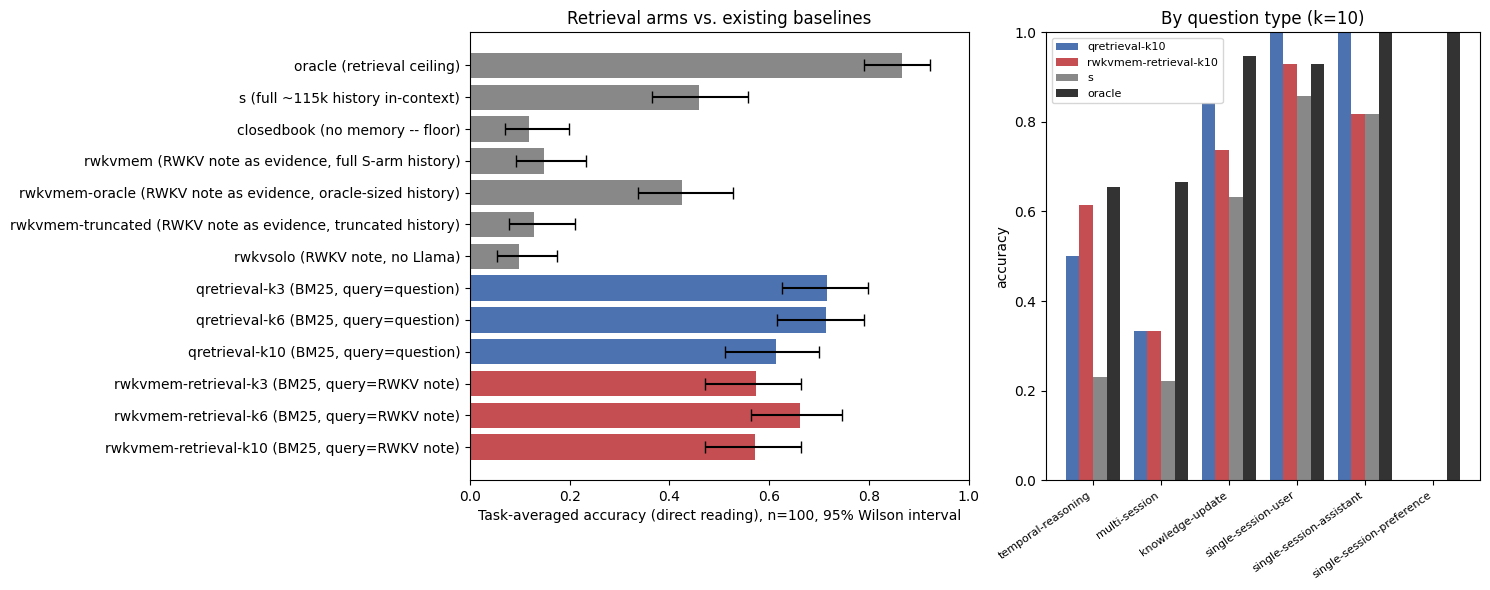


-> /content/drive/MyDrive/Algoverse/lme_openrouter/results/subset100/figures/retrieval_arms.png


In [13]:
import matplotlib.pyplot as plt

_fig_rows = []
for _arm in _order:
    _ta = retrieval_metrics_df[(retrieval_metrics_df.arm == _arm) & (retrieval_metrics_df.metric == "task_averaged")]
    if _ta.empty:
        continue
    r = _ta.iloc[0]
    _fig_rows.append((_label.get(_arm, _arm), _arm, r.value, r.wilson_lo, r.wilson_hi))
_fig_rows = _fig_rows[::-1]

_names = [r[0] for r in _fig_rows]
_arm_ids = [r[1] for r in _fig_rows]
_vals = [r[2] for r in _fig_rows]
_errs_lo = [r[2] - r[3] for r in _fig_rows]
_errs_hi = [r[4] - r[2] for r in _fig_rows]
_colors = ["#c44e52" if a.startswith("rwkvmem-retrieval") else "#4c72b0" if a.startswith("qretrieval") else "#888888"
           for a in _arm_ids]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.barh(_names, _vals, xerr=[_errs_lo, _errs_hi], color=_colors, capsize=4)
ax.set_xlim(0, 1)
ax.set_xlabel("Task-averaged accuracy (direct reading), n=100, 95% Wilson interval")
ax.set_title("Retrieval arms vs. existing baselines")

ax2 = axes[1]
_best_k = max(RETRIEVAL_KS)
_plot_arms = [f"qretrieval-k{_best_k}"]
if CAN_RUN_RWKVMEM_RETRIEVAL:
    _plot_arms.append(f"rwkvmem-retrieval-k{_best_k}")
_plot_arms += ["s", "oracle"]
_bar_colors = {"qretrieval": "#4c72b0", "rwkvmem-retrieval": "#c44e52", "s": "#888888", "oracle": "#333333"}
_width = 0.8 / len(_plot_arms)
_x = list(range(len(QUESTION_TYPES)))
for _i, _arm in enumerate(_plot_arms):
    _accs = []
    for _t in QUESTION_TYPES:
        _row = retrieval_by_type_df[(retrieval_by_type_df.arm == _arm) & (retrieval_by_type_df.question_type == _t)]
        _accs.append(_row.iloc[0].accuracy if not _row.empty else 0.0)
    _color_key = _arm.split("-k")[0] if "-k" in _arm else _arm
    _xs = [xi + _i * _width for xi in _x]
    ax2.bar(_xs, _accs, width=_width, label=_arm, color=_bar_colors.get(_color_key))
ax2.set_xticks([xi + _width * (len(_plot_arms) - 1) / 2 for xi in _x])
ax2.set_xticklabels(QUESTION_TYPES, rotation=35, ha="right", fontsize=8)
ax2.set_ylim(0, 1)
ax2.set_ylabel("accuracy")
ax2.set_title(f"By question type (k={_best_k})")
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_ROOT / "retrieval_arms.png", dpi=150)
plt.show()
print(f"\n-> {FIGURES_ROOT / 'retrieval_arms.png'}")


### 29.26 Verdict, deviations, and provenance

A separate `manifest_retrieval_subset100.json` is written alongside (not merged into) the existing
`manifest_subset100.json` and `manifest_rwkvmem_subset100.json`.

In [14]:
import datetime
import importlib.metadata

import openai


def _metric_val(arm, metric="task_averaged"):
    row = retrieval_metrics_df[(retrieval_metrics_df.arm == arm) & (retrieval_metrics_df.metric == metric)]
    return row.iloc[0].value if not row.empty else None


def _type_val(arm, qtype):
    row = retrieval_by_type_df[(retrieval_by_type_df.arm == arm) & (retrieval_by_type_df.question_type == qtype)]
    if row.empty:
        return None, None
    return row.iloc[0].accuracy, int(row.iloc[0].n)


def _sig(a, b):
    row = significance_df[(significance_df.a == a) & (significance_df.b == b)]
    return row.iloc[0] if not row.empty else None


print("=== VERDICT ===\n")

_best_k = max(RETRIEVAL_KS)
print(f"Overall (task-averaged), best k={_best_k}:")
for _arm in ([f"qretrieval-k{_best_k}"] + ([f"rwkvmem-retrieval-k{_best_k}"] if CAN_RUN_RWKVMEM_RETRIEVAL else [])
             + ["s", "oracle", "closedbook", "rwkvmem"]):
    v = _metric_val(_arm)
    if v is not None:
        print(f"  {_arm:28s} {v:.3f}")

print(f"\nPer-question-type verdict (k={_best_k}):")
for _qtype in QUESTION_TYPES:
    _q_acc, _q_n = _type_val(f"qretrieval-k{_best_k}", _qtype)
    _r_acc, _r_n = (_type_val(f"rwkvmem-retrieval-k{_best_k}", _qtype) if CAN_RUN_RWKVMEM_RETRIEVAL else (None, None))
    _s_acc, _s_n = _type_val("s", _qtype)
    _line = f"  {_qtype:28s} qretrieval={_q_acc:.3f} (n={_q_n})" if _q_acc is not None else f"  {_qtype:28s} qretrieval=n/a"
    if _r_acc is not None:
        _line += f"   rwkvmem-retrieval={_r_acc:.3f} (n={_r_n})"
    if _s_acc is not None:
        _line += f"   s={_s_acc:.3f} (n={_s_n})"
    print(_line)
    if _qtype == "single-session-preference" and _q_n is not None:
        print(f"    (n={_q_n} in this subset -- too small to draw a per-type conclusion on its own)")

print("\nLoad-bearing comparison: does RWKV's note beat plain-question retrieval?")
if CAN_RUN_RWKVMEM_RETRIEVAL:
    for k in RETRIEVAL_KS:
        _row = _sig(f"rwkvmem-retrieval-k{k}", f"qretrieval-k{k}")
        _rv, _qv = _metric_val(f"rwkvmem-retrieval-k{k}"), _metric_val(f"qretrieval-k{k}")
        if _row is None or _rv is None or _qv is None:
            continue
        _holm_val = _row.holm_p if "holm_p" in _row else _row.mcnemar_p
        _beats = _rv > _qv and _row.mcnemar_p < 0.05
        if _beats:
            print(f"  k={k}: rwkvmem-retrieval ({_rv:.3f}) beat qretrieval ({_qv:.3f}), "
                  f"McNemar p={_row.mcnemar_p:.4f} (Holm p={_holm_val:.4f}).")
        else:
            print(f"  k={k}: rwkvmem-retrieval ({_rv:.3f}) did NOT measurably beat qretrieval "
                  f"({_qv:.3f}) -- McNemar p={_row.mcnemar_p:.4f} (Holm p={_holm_val:.4f}). This is "
                  f"a legitimate outcome flagged as plausible in 29.16: plain-question BM25 over "
                  f"~47 candidate sessions may already capture most of the achievable gain on this "
                  f"benchmark's largely explicit-intent questions.")
else:
    print("  Not tested: rwkvmem-retrieval-k{3,6,10} did not run in this environment (RWKV notes "
          "were unavailable -- see the bootstrap cell). Only qretrieval's own results above are "
          "available from this run.")

print("\nDoes retrieval beat dumping the full history (s)?")
for k in RETRIEVAL_KS:
    _row = _sig(f"qretrieval-k{k}", "s")
    _qv, _sv = _metric_val(f"qretrieval-k{k}"), _metric_val("s")
    if _row is None or _qv is None or _sv is None:
        continue
    _holm_val = _row.holm_p if "holm_p" in _row else _row.mcnemar_p
    if _qv > _sv and _row.mcnemar_p < 0.05:
        print(f"  k={k}: qretrieval ({_qv:.3f}) beat s ({_sv:.3f}), McNemar p={_row.mcnemar_p:.4f} "
              f"(Holm p={_holm_val:.4f}).")
    else:
        print(f"  k={k}: qretrieval ({_qv:.3f}) did not measurably beat s ({_sv:.3f}) -- McNemar "
              f"p={_row.mcnemar_p:.4f} (Holm p={_holm_val:.4f}).")

print("\nThis is a checkpoint on n=100, not a definitive result -- read the full per-question-type "
      "table in 29.23 and retrieval_by_question_type.csv before drawing conclusions.")

print("\n=== Known deviations from this spec ===")
DEVIATIONS_FROM_SPEC = [
    "render_session()/render_history()/PROMPT_TEMPLATE_DIRECT/compute_metrics/wilson_ci/"
    "mcnemar_exact_p are transcribed here (a notebook cannot import from another notebook), not "
    "imported from long_mem_eval_v1.ipynb -- Gate F (29.18) checks the transcription against that "
    "notebook's live source instead of merely asserting it matches.",
    "RETRIEVAL_CONCURRENCY=2, not 29.3's RWKVMEM_CONCURRENCY=4 -- that value was justified by "
    "~300-token rwkvmem/closedbook prompts; retrieval prompts here are 9k-32k tokens (k full "
    "sessions), and long_mem_eval_v1.ipynb's own cell 6 already recorded Groq 429-storming this "
    "same reader under concurrent load at long-context sizes.",
    "A Holm-Bonferroni-adjusted p-value is reported alongside each raw McNemar p -- not requested "
    "explicitly, added because ~15-19 contrasts at alpha=0.05 raw would expect roughly one false "
    "positive on their own.",
    "qretrieval-k{3,6,10} vs oracle was added as an extra contrast beyond the three required "
    "families, to show how close plain-question BM25 gets to the retrieval ceiling.",
    "Gate R's smoke probes call generate_one()/judge_one() directly in memory (Gate 4's pattern) "
    "rather than writing through run_synthetic_arm(), so the smoke test never seeds the real arm "
    "files.",
    "BM25 ties are broken deterministically by (-score, session_index) -- not specified by the "
    "task, added because ties are otherwise resolved by whatever order get_scores() returns.",
    "An explicit token-budget assertion was added to build_retrieval_prompt() -- "
    "build_synthetic_prompt_rec's original assumption ('prompts this small never need truncation "
    "logic') does not hold at k=10 (~32k tokens), so the guard is explicit rather than inherited.",
    "The retrieval query is the RWKV note alone or the question alone, never both concatenated -- "
    "per spec. A note+question hybrid (closer to MemoRAG's own formulation, which concatenates the "
    "draft with the query) was deliberately not added as a seventh arm; it is a natural follow-up, "
    "not run here.",
    "single-session-preference has n=3 in this 100-question subset (vs. 30/500 in the full "
    "benchmark) -- its per-question-type numbers above are reported but are not statistically "
    "informative on their own.",
]
if not CAN_RUN_RWKVMEM_RETRIEVAL:
    DEVIATIONS_FROM_SPEC.append(
        f"rwkvmem-retrieval-k{{3,6,10}} did not run in this environment: "
        f"{RUN_ROOT / 'rwkv_notes' / RWKV_ARM_NAME / 's_dialogue.jsonl'} was missing or empty, "
        f"meaning long_mem_eval_v1.ipynb's Sections 29.1-29.9 were not completed against this "
        f"ROOT. Only qretrieval-k{{3,6,10}} ran; the three required rwkvmem-retrieval arms must be "
        f"run in an environment where those notes exist (e.g. Colab, per that notebook's own "
        f"Section 29 design)."
    )

for _dev in DEVIATIONS_FROM_SPEC:
    print(f"  - {_dev}")

MANIFEST_RETRIEVAL = {
    "run_scale": RUN_SCALE, "n_questions": len(QUESTION_SUBSET), "retrieval_ks": RETRIEVAL_KS,
    "can_run_rwkvmem_retrieval": CAN_RUN_RWKVMEM_RETRIEVAL,
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "results": retrieval_metrics_df.to_dict("records"),
    "results_by_question_type": retrieval_by_type_df.to_dict("records"),
    "significance": significance_df.to_dict("records"),
    "deviations_from_spec": DEVIATIONS_FROM_SPEC,
    "package_versions": {
        "rank_bm25": importlib.metadata.version("rank_bm25"),
        "openai": openai.__version__, "pandas": pd.__version__,
    },
}
with open(ROOT / "manifest_retrieval_subset100.json", "w", encoding="utf-8") as f:
    _json.dump(MANIFEST_RETRIEVAL, f, indent=2, default=str)
print(f"\nManifest written to {ROOT / 'manifest_retrieval_subset100.json'}")


=== VERDICT ===

Overall (task-averaged), best k=10:
  qretrieval-k10               0.613
  rwkvmem-retrieval-k10        0.572
  s                            0.460
  oracle                       0.866
  closedbook                   0.118
  rwkvmem                      0.149

Per-question-type verdict (k=10):
  temporal-reasoning           qretrieval=0.500 (n=26)   rwkvmem-retrieval=0.615 (n=26)   s=0.231 (n=26)
  multi-session                qretrieval=0.333 (n=27)   rwkvmem-retrieval=0.333 (n=27)   s=0.222 (n=27)
  knowledge-update             qretrieval=0.842 (n=19)   rwkvmem-retrieval=0.737 (n=19)   s=0.632 (n=19)
  single-session-user          qretrieval=1.000 (n=14)   rwkvmem-retrieval=0.929 (n=14)   s=0.857 (n=14)
  single-session-assistant     qretrieval=1.000 (n=11)   rwkvmem-retrieval=0.818 (n=11)   s=0.818 (n=11)
  single-session-preference    qretrieval=0.000 (n=3)   rwkvmem-retrieval=0.000 (n=3)   s=0.000 (n=3)
    (n=3 in this subset -- too small to draw a per-type conclus